In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from sklearn.metrics import classification_report

In [1]:
import zipfile

with zipfile.ZipFile("FruitinAmazon.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("Dataset folder extracted successfully!")

Dataset folder extracted successfully!


## Task 1: Data Understanding and Visualization

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


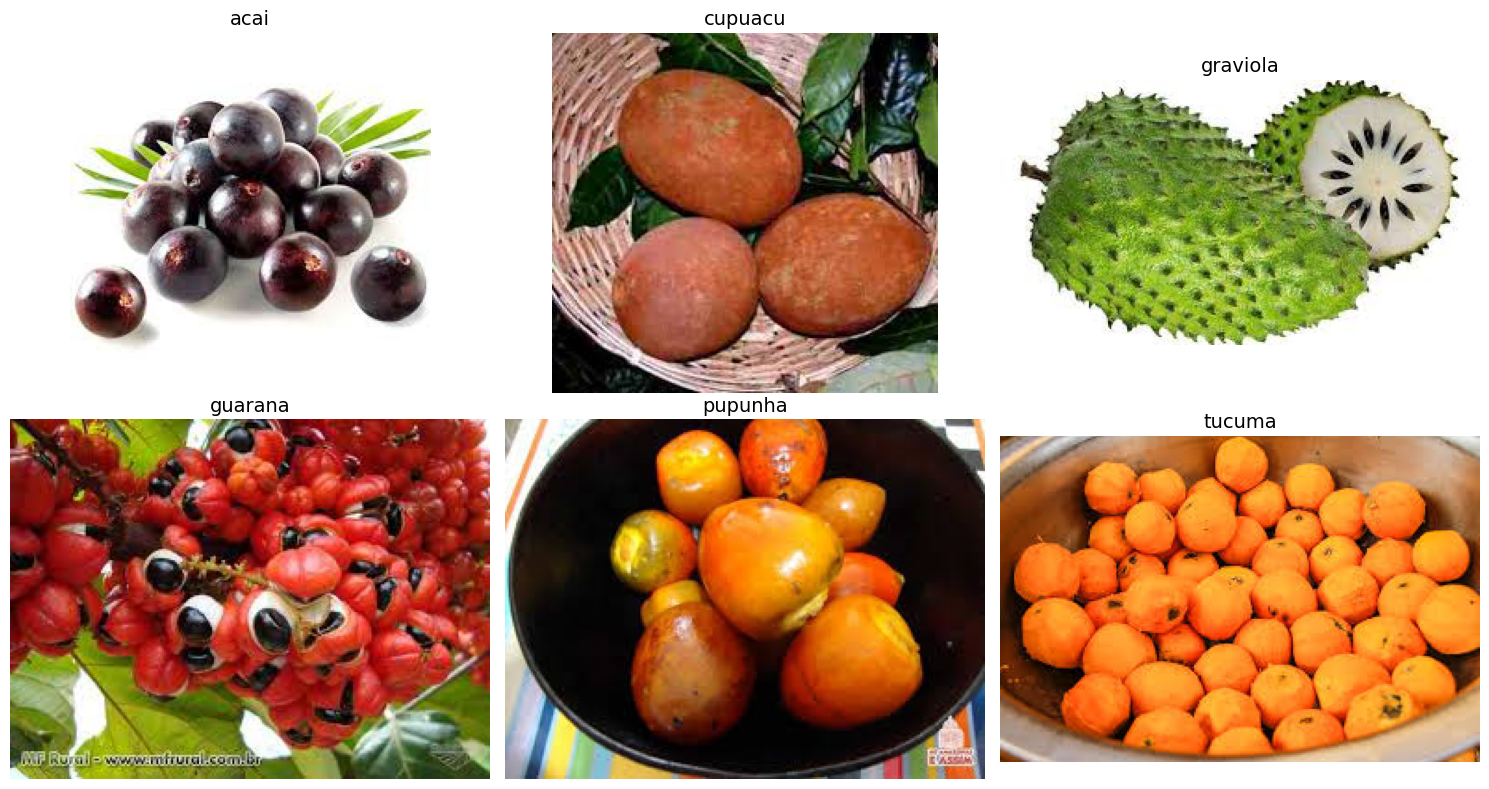

In [5]:
train_dir = 'FruitinAmazon/train'
test_dir = 'FruitinAmazon/test'

# Get the list of class directories from the train folder
class_names = sorted(os.listdir(train_dir))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Select one image randomly from each class
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        if images:
            random_image = random.choice(images)
            image_path = os.path.join(class_path, random_image)
            selected_images.append(image_path)
            selected_labels.append(class_name)

# Display the images in a grid format with two rows using matplotlib
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i, (img_path, label) in enumerate(zip(selected_images, selected_labels)):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=14)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Check for Corrupted Images
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            try:
                img = Image.open(image_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


## Task 2: Loading and Preprocessing Image Data

In [9]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

class_names = train_ds.class_names
num_classes = len(class_names)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print(f"Class names: {class_names}")
print(f"Number of classes: {num_classes}")

for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    print(f"Pixel value range: [{images.numpy().min():.4f}, {images.numpy().max():.4f}]")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel value range: [0.0000, 1.0000]


## Task 3: Implement a CNN

In [11]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", strides=(1, 1),
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same", strides=(1, 1)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

C:\Users\samye\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

In [58]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0358
Epoch 1: val_accuracy improved from None to 0.77778, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 231ms/step - accuracy: 1.0000 - loss: 0.0431 - val_accuracy: 0.7778 - val_loss: 0.4909
Epoch 2/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9766 - loss: 0.0967 
Epoch 2: val_accuracy improved from 0.77778 to 0.83333, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9583 - loss: 0.1597 - val_accuracy: 0.8333 - val_loss: 0.5936
Epoch 3/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9922 - loss: 0.0210 
Epoch 3: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9722 - loss: 0.0646 - val_accuracy: 0.8889 - val_loss: 0.7037
Epoch 4/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9766 - loss: 0.0346 
Epoch 4: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9861 - loss: 0.0325 - val_accuracy: 0.8333 - val_loss: 0.4988
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9531 - loss: 0.0846 
Epoch 5: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9722 - loss: 0.0610 - val_accuracy: 0.8889 - val_loss: 0.3886
Epoch 6/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0169 
Epoch 6: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 0.8889 - val_loss: 0.3015
Epoch 7/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0174 

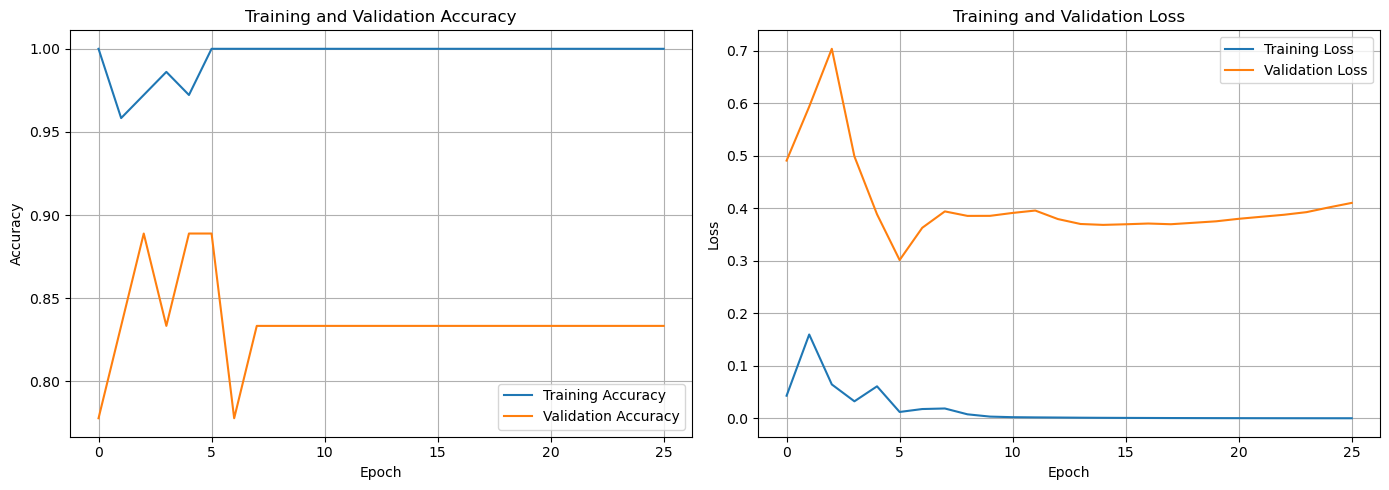

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [62]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

test_class_names = test_ds.class_names
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6000 - loss: 1.5493
Test Loss: 1.5493
Test Accuracy: 0.6000


## Task 6: Save and Load the Model

In [65]:
model.save('fruit_classifier_cnn.h5')
print("Model saved successfully as 'fruit_classifier_cnn.h5'")

loaded_model = keras.models.load_model('fruit_classifier_cnn.h5')
print("Model loaded successfully!")

loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_test_acc:.4f}")

Model saved successfully as 'fruit_classifier_cnn.h5'
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.6000 - loss: 1.5493
Loaded Model - Test Loss: 1.5493
Loaded Model - Test Accuracy: 0.6000


## Task 7: Predictions and Classification Report

In [67]:
all_test_images = []
all_test_labels = []

for images, labels in test_ds:
    all_test_images.append(images.numpy())
    all_test_labels.append(labels.numpy())

all_test_images = np.concatenate(all_test_images, axis=0)
all_test_labels = np.concatenate(all_test_labels, axis=0)

predictions = model.predict(all_test_images)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:", predicted_labels)
print("Actual labels:   ", all_test_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted labels: [0 0 0 0 0 1 2 3 1 1 3 2 2 0 2 4 3 3 3 0 4 1 4 4 4 4 2 0 4 0]
Actual labels:    [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 3 3 3 3 3 4 4 4 4 4 5 5 5 5 5]


In [68]:
report = classification_report(
    all_test_labels,
    predicted_labels,
    target_names=test_class_names
)
print(report)

              precision    recall  f1-score   support

        acai       0.56      1.00      0.71         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.60      0.60      0.60         5
     guarana       0.60      0.60      0.60         5
     pupunha       0.57      0.80      0.67         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.60        30
   macro avg       0.51      0.60      0.54        30
weighted avg       0.51      0.60      0.54        30



C:\Users\samye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\samye\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


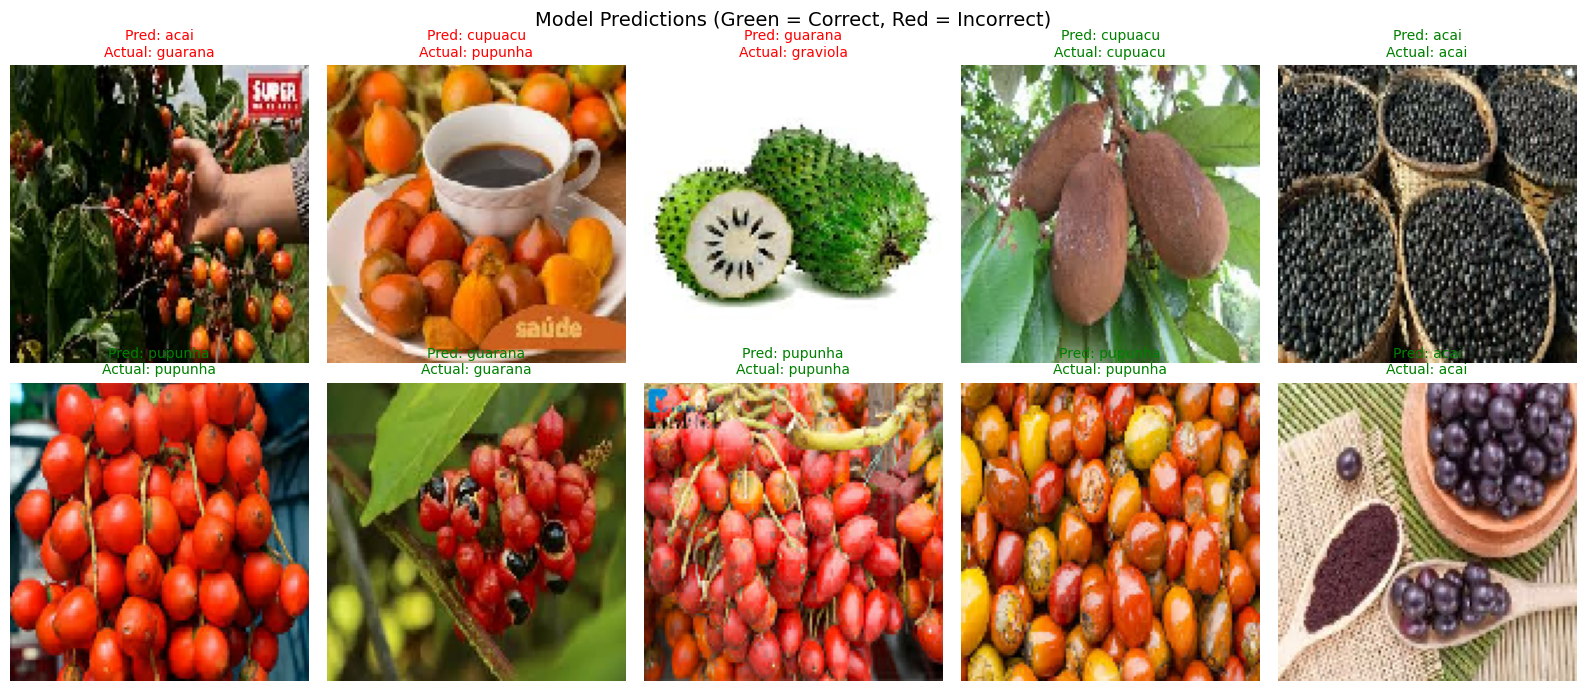

In [70]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

indices = random.sample(range(len(all_test_labels)), min(10, len(all_test_labels)))

for i, idx in enumerate(indices):
    axes[i].imshow(all_test_images[idx])
    actual = test_class_names[all_test_labels[idx]]
    predicted = test_class_names[predicted_labels[idx]]
    color = 'green' if actual == predicted else 'red'
    axes[i].set_title(f"Pred: {predicted}\nActual: {actual}", color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle("Model Predictions (Green = Correct, Red = Incorrect)", fontsize=14)
plt.tight_layout()
plt.show()